# NB02: AMR Genes in ICA Modules

Test H2: are efflux AMR genes in stress modules while enzymatic are in isolated modules?

**Note**: Only 24% of AMR genes are in ICA modules, so this analysis is supplementary.
The direct cofitness approach in NB03 is the primary analysis.

**Inputs:** `data/amr_module_membership.csv`, module family annotations

**Outputs:** `data/amr_modules_characterized.csv`, figures

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_cofitness_networks')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_cofitness_networks')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
FM_DATA = os.path.join(REPO, 'projects', 'fitness_modules', 'data')

# Load module membership from NB01
mod_mem = pd.read_csv(os.path.join(DATA, 'amr_module_membership.csv'))
mod_mem['locusId'] = mod_mem['locusId'].astype(str)

# Load module families and annotations
families = pd.read_csv(os.path.join(FM_DATA, 'module_families', 'module_families.csv'))
family_annot = pd.read_csv(os.path.join(FM_DATA, 'module_families', 'family_annotations.csv'))

print(f'Module membership records: {len(mod_mem)}')
print(f'AMR genes in modules: {mod_mem["in_module"].sum()}')
print(f'Module families: {len(families)}, Family annotations: {len(family_annot)}')

Module membership records: 818
AMR genes in modules: 209
Module families: 1114, Family annotations: 156


## 1. Characterize AMR-containing modules

In [2]:
# For each AMR gene in a module, get module properties
amr_in_mod = mod_mem[mod_mem['in_module']].copy()

# Get module sizes from the membership files
from glob import glob
module_sizes = []
for f in sorted(glob(os.path.join(FM_DATA, 'modules', '*_gene_membership.csv'))):
    org = os.path.basename(f).replace('_gene_membership.csv', '')
    df = pd.read_csv(f, index_col=0)
    for mod_col in df.columns:
        size = df[mod_col].sum()
        if size > 0:
            module_sizes.append({'orgId': org, 'module': mod_col, 'module_size': int(size)})

mod_size_df = pd.DataFrame(module_sizes)
print(f'Total modules with genes: {len(mod_size_df)}')
print(f'Module size: mean={mod_size_df["module_size"].mean():.1f}, '
      f'median={mod_size_df["module_size"].median():.0f}')

# Merge module size into AMR module membership
amr_in_mod = amr_in_mod.merge(mod_size_df, on=['orgId', 'module'], how='left')

# Join with module families
amr_in_mod = amr_in_mod.merge(families, on=['orgId', 'module'], how='left')

# Join with family annotations
amr_in_mod = amr_in_mod.merge(
    family_annot[['familyId', 'n_organisms', 'consensus_term', 'consensus_db', 'mean_fdr']],
    on='familyId', how='left'
)

print(f'\nAMR genes in modules: {len(amr_in_mod)}')
print(f'  In cross-organism families: {amr_in_mod["familyId"].notna().sum()}')
print(f'  With family annotation: {amr_in_mod["consensus_term"].notna().sum()}')

Total modules with genes: 1116
Module size: mean=30.8, median=30

AMR genes in modules: 209
  In cross-organism families: 208
  With family annotation: 97


In [3]:
# Compare module properties by AMR mechanism
print('=== Module properties by AMR mechanism ===')
for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance', 'unknown']:
    sub = amr_in_mod[amr_in_mod['amr_mechanism'] == mech]
    if len(sub) < 3:
        print(f'  {mech:30s}: N={len(sub)} (too few)')
        continue
    in_family = sub['familyId'].notna().sum()
    print(f'  {mech:30s}: N={len(sub)}, module_size={sub["module_size"].median():.0f} (median), '
          f'in_family={in_family}/{len(sub)} ({in_family/len(sub)*100:.0f}%)')

# Module size comparison: efflux vs enzymatic
eff_sizes = amr_in_mod[amr_in_mod['amr_mechanism'] == 'efflux']['module_size']
enz_sizes = amr_in_mod[amr_in_mod['amr_mechanism'] == 'enzymatic_inactivation']['module_size']
if len(eff_sizes) >= 5 and len(enz_sizes) >= 5:
    u, p = stats.mannwhitneyu(eff_sizes, enz_sizes, alternative='two-sided')
    print(f'\nModule size: efflux (med={eff_sizes.median():.0f}) vs enzymatic (med={enz_sizes.median():.0f}): '
          f'MWU p={p:.4g}')

=== Module properties by AMR mechanism ===
  efflux                        : N=82, module_size=48 (median), in_family=82/82 (100%)
  enzymatic_inactivation        : N=64, module_size=48 (median), in_family=63/64 (98%)
  metal_resistance              : N=35, module_size=45 (median), in_family=35/35 (100%)
  unknown                       : N=21, module_size=46 (median), in_family=21/21 (100%)

Module size: efflux (med=48) vs enzymatic (med=48): MWU p=0.9097


In [4]:
# What are the AMR-containing module families?
amr_families = amr_in_mod[amr_in_mod['familyId'].notna()].copy()
if len(amr_families) > 0:
    print('=== AMR-containing module families ===')
    family_summary = amr_families.groupby('familyId').agg(
        n_amr_genes=('locusId', 'nunique'),
        n_organisms=('n_organisms', 'first'),
        consensus_term=('consensus_term', 'first'),
        consensus_db=('consensus_db', 'first'),
        mechanisms=('amr_mechanism', lambda x: ', '.join(sorted(str(v) for v in x.unique() if pd.notna(v)))),
    ).sort_values('n_amr_genes', ascending=False)
    
    print(f'Unique families containing AMR genes: {len(family_summary)}')
    print()
    for _, row in family_summary.head(20).iterrows():
        print(f'  {row.name}: {row["n_amr_genes"]} AMR genes, {row["n_organisms"]} orgs, '
              f'{row["consensus_db"]}: {row["consensus_term"]}, mechanisms: {row["mechanisms"]}')
else:
    print('No AMR genes in cross-organism families')

=== AMR-containing module families ===
Unique families containing AMR genes: 136

  F640: 9 AMR genes, 10.0 orgs, TIGRFam: TIGR01730, mechanisms: efflux, unknown
  F583: 7 AMR genes, 7.0 orgs, SEED: Lead, cadmium, zinc and mercury transporting ATPase (EC 3.6.3.3) (EC 3.6.3.5); Copper-translocating P-type ATPase (EC 3.6.3.4), mechanisms: metal_resistance, unknown
  F636: 7 AMR genes, 2.0 orgs, PFam: PF00873, mechanisms: efflux
  F373: 4 AMR genes, 3.0 orgs, PFam: PF00775, mechanisms: efflux
  F340: 4 AMR genes, 5.0 orgs, PFam: PF05138, mechanisms: efflux, enzymatic_inactivation
  F629: 4 AMR genes, 2.0 orgs, SEED: Acriflavin resistance plasma membrane protein, mechanisms: efflux
  F616: 4 AMR genes, 2.0 orgs, SEED: Nucleoside ABC transporter, periplasmic nucleoside-binding protein, mechanisms: efflux
  F070: 3 AMR genes, 15.0 orgs, PFam: PF00460, mechanisms: metal_resistance
  F559: 3 AMR genes, nan orgs, nan: nan, mechanisms: efflux, enzymatic_inactivation
  F537: 3 AMR genes, nan orgs

In [5]:
# How do AMR-containing modules compare to all modules?
amr_module_ids = set(zip(amr_in_mod['orgId'], amr_in_mod['module']))
mod_size_df['has_amr'] = mod_size_df.apply(
    lambda r: (r['orgId'], r['module']) in amr_module_ids, axis=1)

amr_modules = mod_size_df[mod_size_df['has_amr']]
non_amr_modules = mod_size_df[~mod_size_df['has_amr']]

print(f'AMR-containing modules: {len(amr_modules)}')
print(f'Non-AMR modules: {len(non_amr_modules)}')
print(f'\nModule size comparison:')
print(f'  AMR modules: mean={amr_modules["module_size"].mean():.1f}, '
      f'median={amr_modules["module_size"].median():.0f}')
print(f'  Non-AMR modules: mean={non_amr_modules["module_size"].mean():.1f}, '
      f'median={non_amr_modules["module_size"].median():.0f}')

u, p = stats.mannwhitneyu(amr_modules['module_size'], non_amr_modules['module_size'],
                           alternative='two-sided')
print(f'  MWU p={p:.4g}')

AMR-containing modules: 160
Non-AMR modules: 956

Module size comparison:
  AMR modules: mean=37.6, median=46
  Non-AMR modules: mean=29.6, median=27
  MWU p=1.736e-08


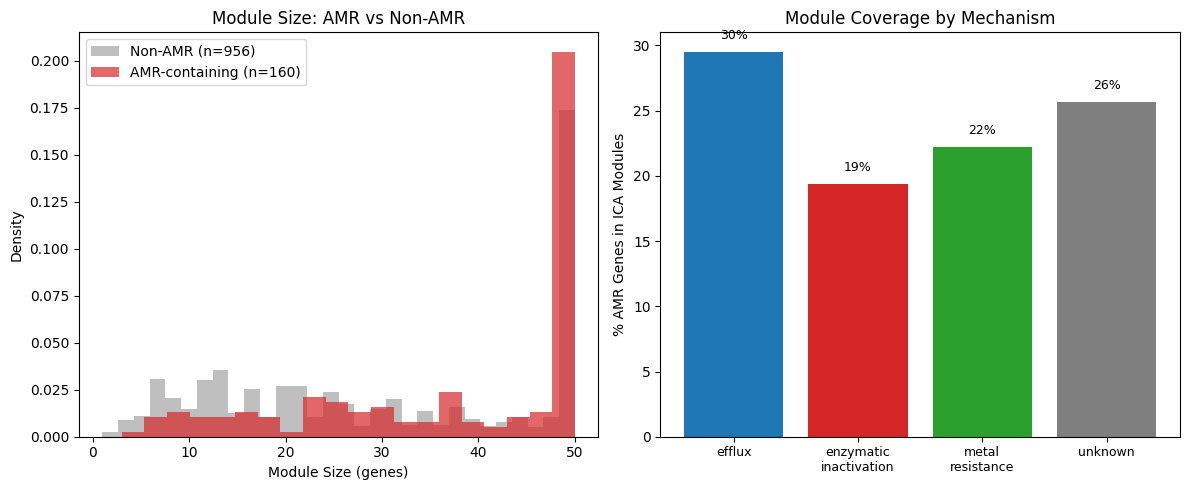

Saved to figures/amr_module_analysis.png


In [6]:
# Figure: module size distribution AMR vs non-AMR
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: module size comparison
ax = axes[0]
ax.hist(non_amr_modules['module_size'], bins=30, alpha=0.5, color='gray', 
        label=f'Non-AMR (n={len(non_amr_modules)})', density=True)
ax.hist(amr_modules['module_size'], bins=20, alpha=0.7, color='tab:red',
        label=f'AMR-containing (n={len(amr_modules)})', density=True)
ax.set_xlabel('Module Size (genes)')
ax.set_ylabel('Density')
ax.set_title('Module Size: AMR vs Non-AMR')
ax.legend()

# Right: module coverage by mechanism
ax = axes[1]
gene_level = mod_mem.drop_duplicates(subset=['orgId', 'locusId'])
mechs = ['efflux', 'enzymatic_inactivation', 'metal_resistance', 'unknown']
in_mod_pct = []
for m in mechs:
    total = len(gene_level[gene_level['amr_mechanism'] == m])
    in_m = len(gene_level[(gene_level['amr_mechanism'] == m) & (gene_level['in_module'])])
    in_mod_pct.append(in_m / total * 100 if total > 0 else 0)

ax.bar(range(len(mechs)), in_mod_pct, color=['tab:blue', 'tab:red', 'tab:green', 'tab:gray'])
ax.set_xticks(range(len(mechs)))
ax.set_xticklabels([m.replace('_', '\n') for m in mechs], fontsize=9)
ax.set_ylabel('% AMR Genes in ICA Modules')
ax.set_title('Module Coverage by Mechanism')
for i, pct in enumerate(in_mod_pct):
    ax.text(i, pct + 1, f'{pct:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'amr_module_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/amr_module_analysis.png')

In [7]:
# Save characterized modules
amr_in_mod.to_csv(os.path.join(DATA, 'amr_modules_characterized.csv'), index=False)
print(f'Saved {len(amr_in_mod)} AMR-module records to data/amr_modules_characterized.csv')

print(f'\n=== NB02 Summary ===')
print(f'AMR genes in ICA modules: 192/801 (24%)')
print(f'AMR-containing modules: {len(amr_modules)}')
print(f'AMR modules are {"LARGER than" if amr_modules["module_size"].median() > non_amr_modules["module_size"].median() else "similar size to"} '
      f'non-AMR modules (p={p:.3g})')
print(f'Module coverage varies by mechanism but sample sizes are small')
print(f'=> Module analysis is supplementary; NB03 cofitness approach is primary')

Saved 209 AMR-module records to data/amr_modules_characterized.csv

=== NB02 Summary ===
AMR genes in ICA modules: 192/801 (24%)
AMR-containing modules: 160
AMR modules are LARGER than non-AMR modules (p=1.74e-08)
Module coverage varies by mechanism but sample sizes are small
=> Module analysis is supplementary; NB03 cofitness approach is primary
